# Materials Atlas — Python Environment and Jupyter Workflow

**Your first computational materials notebook.** Learn the notebook habits that make scientific work inspectable, repeatable, and easy to extend.

- **Estimated duration:** 60–75 minutes
- **Prerequisites:** Comfort reading software code; no prior Jupyter experience required
- **Required packages:** Python 3, NumPy, Matplotlib

> This is not a Python syntax course. We introduce only the tools you will use to ask and answer materials-science questions.

## Learning objectives

By the end of this notebook, you will be able to:

- describe what a Jupyter notebook is and why scientists use it;
- distinguish Markdown, code, and output cells;
- run cells, read execution order, and manage the Kernel;
- create and inspect variables;
- import NumPy and Matplotlib;
- make a small array and a simple plot;
- recognize common notebook errors and recover from them;
- use a reproducible notebook workflow.

## 1. Why Jupyter?

A Jupyter notebook is a document that combines **explanation**, **executable code**, and **the resulting output**. It lets a scientific argument live beside the calculation that supports it.

In research, that combination matters. A figure without its assumptions is hard to trust; a derivation without a runnable implementation is hard to reuse. Notebooks support quick experiments while retaining a record someone else can inspect and rerun.

Notebooks are therefore a useful *laboratory bench* for computational work: change one condition, run the calculation, observe the result, and record what it means.

### Materials Atlas Connection

Later notebooks will use this same pattern to compute lattice geometry, visualize energy landscapes, and compare simulation results. The notebook is the place where a scientific question becomes a traceable computational experiment.

## 2. Notebook anatomy

A notebook is made from cells. A **Markdown cell** communicates the scientific story. A **code cell** sends Python to the Kernel. The **output** is the evidence produced by that execution.

The number in `In [ ]` (or beside a cell in some interfaces) records execution order, not its position on the page. A cell near the bottom can run first—an important source of confusion.

```mermaid
flowchart LR

M[Markdown cell]
C[Code cell]
K[Kernel]
O[Output]

M --> C
C --> K
K --> O
```

This diagram answers one question: **how does a notebook cell become an observed result?** Markdown does not execute; code does, through the Kernel.

## 3. Running your first cell

Click the next cell and run it with **Shift+Enter**. That shortcut executes the current cell and selects the next one. You can also use the Run button in the notebook interface.

`print()` displays a value. Python can also evaluate arithmetic and combine text. These small examples establish the execution loop you will use throughout the Atlas: write a focused idea, run it, then interpret the output.

In [1]:
print("Welcome to Materials Atlas!")
print(2 + 3)
print("crystal " + "structure")

Welcome to Materials Atlas!
5
crystal structure


After execution, the notebook stores the output below the cell and marks the cell with an execution count. That record is useful, but it is not a guarantee of correctness: code may have been run in a different order. Later we will learn how to reset and verify a notebook.

### Experiment

Change one number or one word in the previous cell. Predict the output before you run it, then run the cell. This small prediction habit turns execution from button-clicking into an experiment.

### Reflection

What changed: the code, the output, or both? In a scientific notebook, write down a surprising answer in Markdown before moving on.

### Materials Atlas Connection

The same run–observe–interpret loop will be used to test how a parameter changes a calculated property. The examples will become richer; the workflow stays the same.

## 4. Variables and notebook state

A variable gives a name to a value. The Kernel remembers that name after a cell finishes, so a later cell can use it. This remembered collection of names and values is called the notebook's **state**.

State is convenient for exploration, but it means your result can depend on earlier actions that are no longer obvious from the current cell.

In [2]:
material_name = "aluminum"
melting_point_kelvin = 933

print(f"Material: {material_name}")
print(f"Approximate melting point: {melting_point_kelvin} K")

Material: aluminum
Approximate melting point: 933 K


In [3]:
# This cell works because the Kernel remembers variables from the cell above.
print(f"{material_name.title()} is stored in the current notebook state.")

Aluminum is stored in the current notebook state.


### Experiment

Change `material_name` and `melting_point_kelvin`, run the first variable cell, then run the second. Notice that the second cell uses the most recently stored values.

### Reflection

If you gave this notebook to a colleague, could they tell which values are currently in memory just by reading one cell? That question motivates reproducible execution.

### Materials Atlas Connection

Later, variables will hold physical constants, lattice parameters, temperatures, and model settings. Clear names make scientific assumptions easier to audit.

## 5. Markdown is part of the computation

Markdown cells turn a notebook from a transcript into an explanation. Double-click this cell (or press Enter) to edit it, then use **Shift+Enter** to render it again.

Markdown supports headings, **bold text**, lists, equations such as $E = mc^2$, and fenced code blocks:

```python
lattice_parameter = 3.61
```

Use Markdown for reasoning, assumptions, units, and interpretation. Prefer it to long code comments because Markdown is readable without asking the reader to parse executable details.

### Experiment

Add a Markdown cell below this one. Give it a heading, one bullet list, and one sentence explaining why a quantity has units. Then render it.

### Materials Atlas Connection

Materials data is meaningful only with context: composition, structure, temperature, units, method, and uncertainty. Markdown is where that context travels with the computation.

## 6. Importing packages

Python packages extend the standard language. We will use:

- **NumPy** for efficient numerical arrays;
- **Matplotlib** for scientific figures.

`import ... as ...` gives a short, conventional name. We will use `np` and `plt` throughout the series. Imports normally belong near the beginning of a notebook so its dependencies are visible.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")

NumPy version: 2.5.1


### Reflection

Why import explicitly rather than relying on a package another cell happened to import? Explicit imports let a clean Kernel reproduce the notebook.

### Materials Atlas Connection

NumPy and Matplotlib are foundational tools for arrays of atom positions, tabulated energies, time-series simulations, and nearly every figure in this curriculum.

## 7. Arrays: small containers for scientific data

A NumPy array stores a collection of numerical values with a shared shape. An array is more than a Python list: it supports fast, clear operations on many values at once.

For now, treat it as an organized set of measurements. We are not doing linear algebra yet; we are building the representation that later makes vectors, matrices, and fields natural.

In [9]:
temperatures_kelvin = np.array([300.0, 600.0, 900.0])

print("Temperatures (K):", temperatures_kelvin)
print("Number of measurements:", temperatures_kelvin.size)
print("Temperatures shifted by 10 K:", temperatures_kelvin + 10)

Temperatures (K): [300. 600. 900.]
Number of measurements: 3
Temperatures shifted by 10 K: [310. 610. 910.]


The expression `temperatures_kelvin + 10` adds 10 to every element. This elementwise thinking is central to scientific computing: a single line can express the same operation over a whole set of measurements.

### Experiment

Replace the three temperatures with three values of your own and run the cell. What does `.size` report?

### Materials Atlas Connection

Arrays will represent lattice vectors, atom coordinates, energies sampled across a structure, and properties evaluated over temperature or time.

## 8. Your first plot

A plot makes a numerical relationship visible. In Matplotlib, a **figure** is the whole canvas and an **axes** object is the coordinate system where data is drawn. `ax.plot(...)` draws the relationship; `plt.show()` displays the completed figure.

This example is intentionally simple. It shows a hypothetical property rising with temperature; it is not a physical model of a specific material.

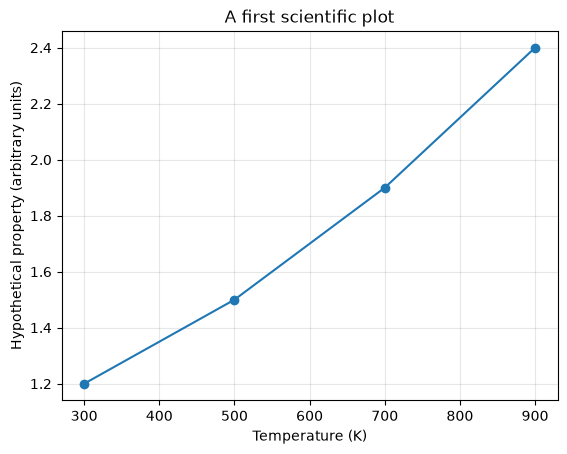

In [10]:
temperature = np.array([300, 500, 700, 900])
hypothetical_property = np.array([1.2, 1.5, 1.9, 2.4])

fig, ax = plt.subplots()
ax.plot(temperature, hypothetical_property, marker="o")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Hypothetical property (arbitrary units)")
ax.set_title("A first scientific plot")
ax.grid(True, alpha=0.3)
plt.show()

### Experiment

Change one property value, predict how the line will move, and rerun the plot. Keep the axis labels: labels and units are part of the scientific claim.

### Reflection

What can you see in the plot that is harder to notice in the raw array? What information would you still need before drawing a scientific conclusion?

### Materials Atlas Connection

Plots will become essential when we compare energy versus structure, phase behavior versus temperature, and simulation results versus reference data.

## 9. Understanding the Kernel

The **Kernel** is the Python process that executes code and holds notebook state in memory. Restarting the Kernel clears that memory. It does not erase the notebook file, but it makes variables, imports, and previous results unavailable until their cells run again.

Use **Restart Kernel** when the state feels uncertain. Then use **Run All** (or run every cell from top to bottom) to test whether the notebook genuinely works from a clean start.

In [11]:
kernel_demo_value = "I exist only while this Kernel is running."
print(kernel_demo_value)

I exist only while this Kernel is running.


### Experiment: restart safely

1. Run the cell above.
2. Restart the Kernel from the notebook menu.
3. Run the next cell **by itself**. It should raise a `NameError`.
4. Run the defining cell again, then rerun the next cell.

Do this experiment deliberately: the error is evidence that memory was cleared.

In [8]:
# Run this after the restart experiment.
print(kernel_demo_value)

I exist only while this Kernel is running.


### Materials Atlas Connection

Scientific notebooks often run for minutes or hours. A clean restart and top-to-bottom run protect against hidden dependencies, stale variables, and figures produced from an accidental state.

## 10. Common beginner mistakes

Errors are useful observations: they describe a mismatch between Python's expectations and the notebook state. Read the final line first, then inspect the named cell and variable. The next examples catch errors so this notebook remains executable from top to bottom.

In [12]:
# NameError: a name has not been defined in the current Kernel.
try:
    print(not_yet_defined)
except NameError as error:
    print(f"NameError caught: {error}")
    print("Fix: run the defining cell, or correct the variable name.")

NameError caught: name 'not_yet_defined' is not defined
Fix: run the defining cell, or correct the variable name.


In [13]:
# SyntaxError: Python cannot parse the code.
broken_example = "print('missing closing parenthesis'"
try:
    compile(broken_example, "<example>", "exec")
except SyntaxError as error:
    print(f"SyntaxError caught: {error.msg}")
    print("Fix: inspect punctuation, indentation, and quotation marks.")

SyntaxError caught: '(' was never closed
Fix: inspect punctuation, indentation, and quotation marks.


In [11]:
# ModuleNotFoundError: the requested package is unavailable in this environment.
try:
    import materials_atlas_package_that_does_not_exist
except ModuleNotFoundError as error:
    print(f"ModuleNotFoundError caught: {error.name}")
    print("Fix: check the package name and install it in the active environment.")

ModuleNotFoundError caught: materials_atlas_package_that_does_not_exist
Fix: check the package name and install it in the active environment.


**Out-of-order execution** is subtler: a cell can appear correct while depending on a variable created somewhere else. Its remedy is the same as for uncertain state: restart the Kernel and run top-to-bottom.

### Materials Atlas Connection

Debugging numerical work begins with the same discipline: identify the message, make the smallest test, check assumptions, and rerun from a known state.

## 11. Notebook best practices

- **One idea per cell.** Small cells make it easier to test, explain, and revise one assumption at a time.
- **Explain before coding.** State the question and expected behavior before producing an output.
- **Prefer Markdown for narrative.** It separates scientific reasoning from implementation details.
- **Keep imports and settings visible.** A reader can see what the notebook needs.
- **Run top-to-bottom regularly.** This reveals hidden state and out-of-order dependencies.
- **Restart the Kernel before sharing.** A clean run is a practical reproducibility check.
- **Label plots and record units.** An unlabeled figure cannot support a careful scientific claim.

These are not stylistic rituals. They make your work easier for a future collaborator—and for future you—to trust.

## 12. Scientific workflow

A notebook supports an iterative research cycle. The result of one calculation is not the end of the work; it informs interpretation and the next experiment.

```mermaid
flowchart LR

Q[Question]
H[Hypothesis]
C[Code]
R[Result]
I[Interpretation]
N[Next Experiment]

Q --> H
H --> C
C --> R
R --> I
I --> N
N --> Q
```

This diagram answers one question: **how does a notebook support a scientific investigation?**

### Materials Atlas Connection

In later modules, a question such as “How does crystal structure influence energy?” will become a hypothesis, a calculation, a plotted result, and a new question. The notebook provides the connective tissue between each stage.

## 13. Mini exercise — make your own tiny experiment

Choose a material label and invent three temperatures with a simple property value at each temperature. Then:

1. Edit the variables in the next code cell.
2. Run it to create a NumPy array and a plot.
3. Add a Markdown cell below it explaining the trend you chose, including the units and whether the values are hypothetical.

There is no intended physical conclusion here. The goal is a complete notebook loop: assumptions → code → figure → explanation.

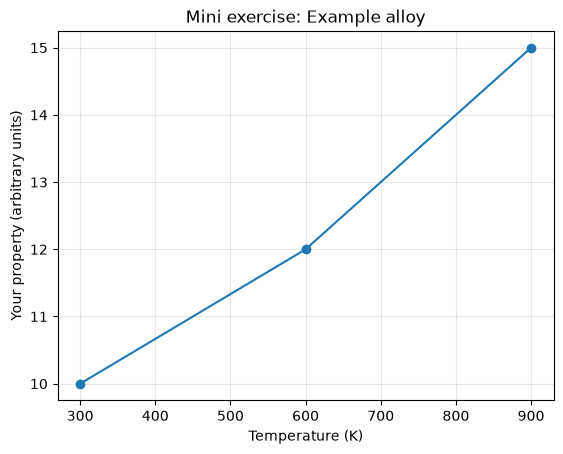

In [12]:
# Replace these example values with your own.
exercise_material = "Example alloy"
exercise_temperature = np.array([300, 600, 900])  # K
exercise_property = np.array([10.0, 12.0, 15.0])  # arbitrary units

fig, ax = plt.subplots()
ax.plot(exercise_temperature, exercise_property, marker="o")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Your property (arbitrary units)")
ax.set_title(f"Mini exercise: {exercise_material}")
ax.grid(True, alpha=0.3)
plt.show()

### Self-check

- Can you point to the variables that define your experiment?
- Can you say what each axis means and which units it uses?
- Would a colleague know which values are hypothetical?
- After restarting the Kernel, does **Run All** reproduce your result?

## 14. Reflection

Before continuing, answer these in your own words:

1. What information is stored in the notebook file, and what information lives only in the Kernel?
2. Why can an execution count be misleading?
3. Which part of a scientific claim belongs in Markdown rather than code?
4. How would you check that a notebook is reproducible?
5. Where might an array and a plot help you reason about a materials problem?

Understanding these ideas matters more than memorizing shortcuts.

## 15. Continue with

Continue to **[01-linear-algebra.ipynb](01-linear-algebra.ipynb)**. Linear algebra is the natural next step because arrays gain scientific power when they represent vectors, matrices, directions, and transformations—the language used for crystal geometry, forces, and simulations.

Carry forward one habit: before every computation, make the question, assumptions, and expected observation visible.